#### Outliers Detection & Removal - Using Z-Score

In [19]:
import pandas as pd
import numpy as np

In [20]:
# ─── Inline Dataset: Zomato Delivery Data ───
data = {
    'rider':         ['Raju',  'Suresh', 'Amit',  'Pooja', 'Kiran',
                       'Deepak','Meena',  'Arjun', 'Sunita','Vikram'],
    'delivery_time': [28,     32,      29,     185,    31,
                       27,     30,      26,     220,    33],   # minutes
    'rating':        [4.5,    4.2,     4.6,    4.0,    4.4,
                       4.7,    4.3,     4.8,    3.9,    4.1],
    'orders_today':  [12,     15,      11,     13,     14,
                       10,     16,      9,      12,     15],
}
df = pd.DataFrame(data)

print("Original Data:")
df

Original Data:


,rider,delivery_time,rating,orders_today
0,Raju,28,4.5,12
1,Suresh,32,4.2,15
2,Amit,29,4.6,11
3,Pooja,185,4.0,13
4,Kiran,31,4.4,14
5,Deepak,27,4.7,10
6,Meena,30,4.3,16
7,Arjun,26,4.8,9
8,Sunita,220,3.9,12
9,Vikram,33,4.1,15


In [21]:
# ══════════════════════════════════════════
# STEP 1: Z-Score Calculate karo
# ══════════════════════════════════════════

# delivery_time column pe Z-Score lagao

mean_val = df['delivery_time'].mean()
std_val  = df['delivery_time'].std()

print(f"\nDelivery Time — Mean: {mean_val:.1f} min")
print(f"Delivery Time — Std Dev: {std_val:.1f} min")

# Har row ka Z-Score nikaalo
df['z_score'] = (df['delivery_time'] - mean_val) / std_val

print("\nZ-Scores for delivery_time:")
print(df[['rider', 'delivery_time', 'z_score']].round(2))


Delivery Time — Mean: 64.1 min
Delivery Time — Std Dev: 73.4 min

Z-Scores for delivery_time:
    rider  delivery_time  z_score
0    Raju             28    -0.49
1  Suresh             32    -0.44
2    Amit             29    -0.48
3   Pooja            185     1.65
4   Kiran             31    -0.45
5  Deepak             27    -0.51
6   Meena             30    -0.46
7   Arjun             26    -0.52
8  Sunita            220     2.12
9  Vikram             33    -0.42


In [22]:
# ══════════════════════════════════════════
# STEP 2: Outliers Identify karo (|Z| > 3)
# ══════════════════════════════════════════
threshold = 3
outliers = df[df['z_score'].abs() > threshold]
print(f"\nOutliers detected (|Z| > {threshold}):")
print(outliers[['rider', 'delivery_time', 'z_score']])


Outliers detected (|Z| > 3):
Empty DataFrame
Columns: [rider, delivery_time, z_score]
Index: []


In [23]:
# ══════════════════════════════════════════
# STEP 3: Outliers Remove karo
# ══════════════════════════════════════════
df_clean = df[df['z_score'].abs() <= threshold].copy()
df_clean = df_clean.drop(columns=['z_score'])  # helper column hata do

print(f"\nRows before cleaning: {len(df)}")
print(f"Rows after cleaning:  {len(df_clean)}")
print(f"Outliers removed:     {len(df) - len(df_clean)}")

print("\nMean delivery time BEFORE:", round(df['delivery_time'].mean(), 1), "min")
print("Mean delivery time AFTER: ", round(df_clean['delivery_time'].mean(), 1), "min")
# BEFORE: ~62 min (185 aur 220 ki wajah se)
# AFTER:  ~29 min (real average!)


Rows before cleaning: 10
Rows after cleaning:  10
Outliers removed:     0

Mean delivery time BEFORE: 64.1 min
Mean delivery time AFTER:  64.1 min


#### Outliers Detection & Removal - Using IQR Method

In [6]:
# ─── Inline Dataset: IPL Match Scores ───
data = {
    'match':  ['M1','M2','M3','M4','M5','M6','M7','M8','M9','M10','M11','M12'],
    'team_A': [165, 172, 158, 48,  170, 162, 168, 175, 310, 160, 163, 169],
    'team_B': [155, 160, 145, 152, 158, 310, 148, 162, 155, 42,  157, 153],
}
df = pd.DataFrame(data)

print("Original Data:")
df

Original Data:


,match,team_A,team_B
0,M1,165,155
1,M2,172,160
2,M3,158,145
3,M4,48,152
4,M5,170,158
5,M6,162,310
6,M7,168,148
7,M8,175,162
8,M9,310,155
9,M10,160,42


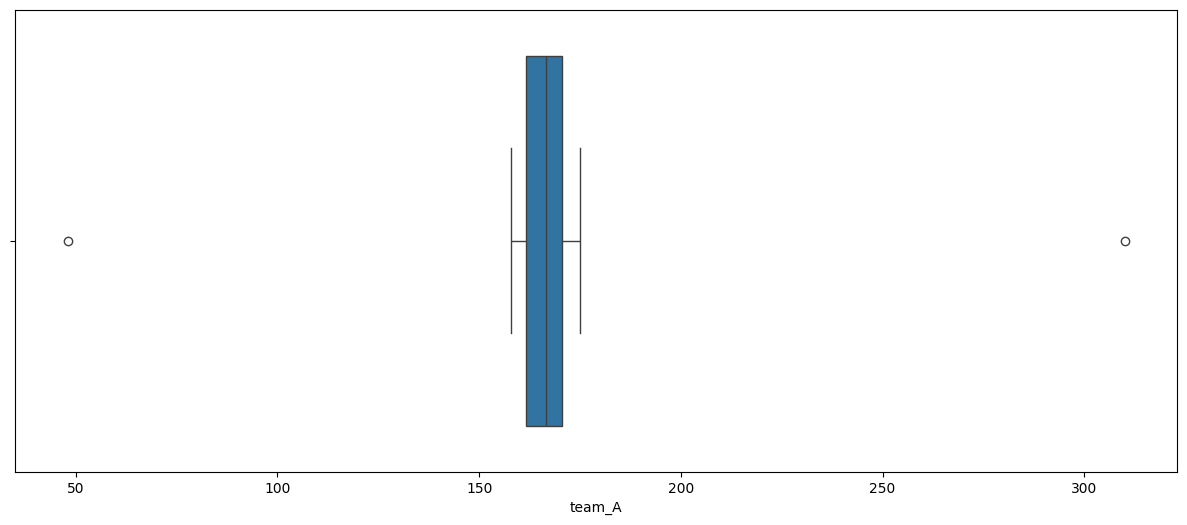

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

sns.boxplot(data=df, x="team_A")

plt.show()

In [8]:
# ══════════════════════════════════════════
# IQR METHOD — team_A column pe apply karo
# ══════════════════════════════════════════

# STEP 1: Q1 aur Q3 nikalo
Q1 = df['team_A'].quantile(0.25)   # 25th percentile
Q3 = df['team_A'].quantile(0.75)   # 75th percentile
IQR = Q3 - Q1

print(f"\n--- team_A Analysis ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Q3 - Q1):        {IQR}")


--- team_A Analysis ---
Q1 (25th percentile): 161.5
Q3 (75th percentile): 170.5
IQR (Q3 - Q1):        9.0


In [9]:
# STEP 2: Fences calculate karo
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"\nLower Fence: {lower_fence}  (is se neeche = outlier)")
print(f"Upper Fence: {upper_fence}  (is se upar  = outlier)")


Lower Fence: 148.0  (is se neeche = outlier)
Upper Fence: 184.0  (is se upar  = outlier)


In [10]:
# STEP 3: Outliers identify karo
outlier_mask = (df['team_A'] < lower_fence) | (df['team_A'] > upper_fence)
print(f"\nOutliers in {'team_A'}:")
print(df[outlier_mask][['match', 'team_A']])


Outliers in team_A:
  match  team_A
3    M4      48
8    M9     310


In [11]:
data_mask = (df['team_A'] > lower_fence) & (df['team_A'] < upper_fence)
print(f"\nGenuine Data in {'team_A'}:")
print(df[data_mask][['match', 'team_A']])


Genuine Data in team_A:
   match  team_A
0     M1     165
1     M2     172
2     M3     158
4     M5     170
5     M6     162
6     M7     168
7     M8     175
9    M10     160
10   M11     163
11   M12     169


In [12]:
# STEP 4: Clean data — outliers remove karo
df_clean = df[~outlier_mask].copy()

print(f"\nRows before: {len(df)} | Rows after: {len(df_clean)}")
print(f"Outliers removed: {outlier_mask.sum()}")
print(f"\nMean team_A BEFORE: {df['team_A'].mean():.1f}")
print(f"Mean team_A AFTER:  {df_clean['team_A'].mean():.1f}")


Rows before: 12 | Rows after: 10
Outliers removed: 2

Mean team_A BEFORE: 168.3
Mean team_A AFTER:  166.2


In [13]:
df_clean

,match,team_A,team_B
0,M1,165,155
1,M2,172,160
2,M3,158,145
4,M5,170,158
5,M6,162,310
6,M7,168,148
7,M8,175,162
9,M10,160,42
10,M11,163,157
11,M12,169,153


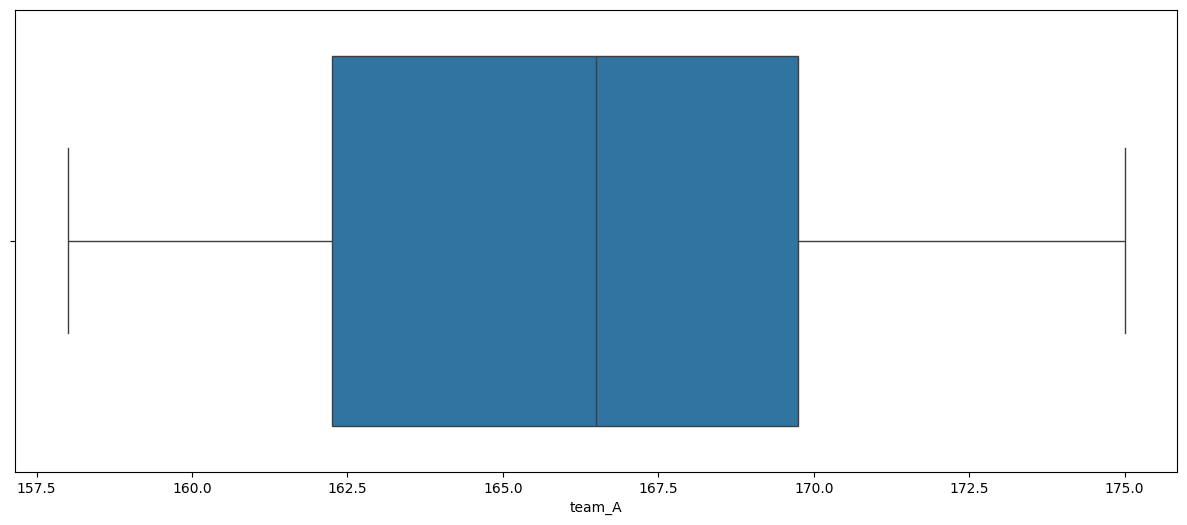

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

sns.boxplot(data=df_clean, x="team_A")

plt.show()